In [2]:
print("Hello, World!")

Hello, World!


In [1]:
class MyDescriptor:
    """一个基础的描述符类"""
    
    def __init__(self, name):
        self.name = name
    
    def __get__(self, instance, owner):
        """获取属性值时调用"""
        print(f"__get__ 被调用：instance={instance}, owner={owner}")
        return f"这是 {self.name} 的值"
    
    def __set__(self, instance, value):
        """设置属性值时调用"""
        print(f"__set__ 被调用：instance={instance}, value={value}")
        if not isinstance(value, str):
            raise TypeError("值必须是字符串！")
        # 通常将值存储在 instance 的 __dict__ 中
        instance.__dict__[self.name] = value
    
    def __delete__(self, instance):
        """删除属性时调用"""
        print(f"__delete__ 被调用")
        del instance.__dict__[self.name]


class MyClass:
    # 将描述符作为类属性
    attr = MyDescriptor("attr")
    
    def __init__(self, value):
        self.attr = value  # 这会触发 __set__


# 使用示例
obj = MyClass("hello")
print(obj.attr)  # 这会触发 __get__

__set__ 被调用：instance=<__main__.MyClass object at 0x000001FC1FDF23C0>, value=hello
__get__ 被调用：instance=<__main__.MyClass object at 0x000001FC1FDF23C0>, owner=<class '__main__.MyClass'>
这是 attr 的值


In [4]:
class LazyProperty:
    """延迟计算并缓存结果的描述符"""
    
    def __init__(self, func):
        self.func = func
        self.name = func.__name__
    
    def __get__(self, instance, owner):
        if instance is None:
            return self
        # 计算一次后缓存结果
        value = self.func(instance)
        setattr(instance, self.name, value)  # 替换描述符
        return value

class ExpensiveComputation:
    def __init__(self, value):
        self.value = value
    
    @LazyProperty
    def expensive_result(self):
        print("执行昂贵的计算...")
        return self.value ** 2

obj = ExpensiveComputation(10)
print(obj.expensive_result)  # 执行计算
print(obj.expensive_result)  # 直接返回缓存结果

执行昂贵的计算...
100
100


In [5]:
# ========== 例子1：描述符就是个"保安" ==========
# 描述符的作用：拦截你对属性的"读/写/删"操作，在里面加自己的逻辑

class Guard:
    """保安描述符：监视对 age 的一切操作"""
    def __get__(self, instance, owner):
        print(f"读取 age，当前值: {instance._age}")
        return instance._age
    
    def __set__(self, instance, value):
        print(f"设置 age = {value}，先检查是不是数字...")
        if not isinstance(value, (int, float)):
            raise TypeError("年龄必须是数字！")
        if value < 0 or value > 150:
            raise ValueError("年龄必须在 0-150 之间！")
        instance._age = value
    
    def __delete__(self, instance):
        print("删除了 age")
        del instance._age


class Person:
    age = Guard()  # age 属性被"保安"看管起来了
    
    def __init__(self, name, age):
        self.name = name
        self.age = age  # 触发 __set__


# 测试
p = Person("小明", 18)   # 触发 __set__
print(p.age)              # 触发 __get__
# p.age = -5              # 报错：年龄超出范围
# p.age = "abc"           # 报错：不是数字

设置 age = 18，先检查是不是数字...
读取 age，当前值: 18
18


In [ ]:
# ========== 例子2：描述符 vs @property（最大优势 = 复用）==========
# 写一次校验逻辑，多个属性都能用

class PositiveNumber:
    """只能存正数的描述符"""
    def __init__(self, name):
        self.name = name
    
    def __get__(self, instance, owner):
        return instance.__dict__[self.name]
    
    def __set__(self, instance, value):
        if value <= 0:
            raise ValueError(f"{self.name} 必须是正数！")
        instance.__dict__[self.name] = value


class Order:
    """订单类：多个字段都需要"正数"校验"""
    price = PositiveNumber("price")       # 复用！
    quantity = PositiveNumber("quantity")  # 复用！
    discount = PositiveNumber("discount")  # 复用！
    
    def __init__(self, price, quantity, discount):
        self.price = price
        self.quantity = quantity
        self.discount = discount
    
    def total(self):
        return self.price * self.quantity - self.discount


o = Order(100, 3, 20)
print(f"总价: {o.total()}")  # 280
# o.price = -10  # 报错！price 必须是正数

In [ ]:
# ========== 例子3：最常见的描述符—— @property ==========
# 你可能没用过描述符，但你一定用过 @property
# @property 底层就是一个描述符！

class Circle:
    def __init__(self, radius):
        self.radius = radius
    
    @property
    def area(self):
        """@property 本质上是描述符的 __get__"""
        return 3.14 * self.radius ** 2
    
    @property
    def circumference(self):
        return 2 * 3.14 * self.radius


c = Circle(5)
print(f"半径: {c.radius}")
print(f"面积: {c.area}")         # 像属性一样读，实际上是方法
print(f"周长: {c.circumference}") # 像属性一样读，实际上是方法
# c.area = 100  # 报错！没有定义 __set__，所以是"只读"的

In [ ]:
# ========== 总结：一句话记住描述符 ==========
# 描述符 = 一个类，里面写了 __get__ / __set__ / __delete__
# 作用 = 拦截另一个类的属性操作，在里面加自定义逻辑
# 优势 = 写一次校验逻辑，多个类/多个属性都能复用
# 你每天都在用 = @property、@classmethod、@staticmethod 都是描述符

In [6]:
class person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

p1 = person("Alice", 30)
print(p1.name)
p1.age = 31
print(p1.age)

Alice
31


In [1]:
isinstance(42, int)           # True
isinstance(3.14, (int, float))  # True，因为 3.14 是 float
isinstance("hello", str)      # True
isinstance([1, 2], list)      # True
isinstance(42, str)           # False

False

In [13]:
class Person:
    age = 0  # 定义一个类属性，初始值为0
    def __init__(self, name):
        self.name = name

p = Person("小明")
print(p.age)  # 0

0


In [17]:
class Circle:
    pi = 3.14159  # 所有圆实例共享这个值
    
    def __init__(self, radius):
        self.radius = radius  # 实例属性
        
    def area(self):
        return self.pi * self.radius ** 2

c1 = Circle(2)
c2 = Circle(3)
print(c1.pi)  # 3.14159
print(c2.pi)  # 3.14159
print(c1.area())  # 12.56636
print(Circle.pi)  # 3.14159

print("Circle.__dict__:", Circle.__dict__)
print("c1.__dict__:", c1.__dict__)


# 输出：
# Circle.__dict__: {..., 'pi': 3.14159, ...}
# c1.__dict__: {'radius': 2}

print(id(c1.pi))      # 内存地址
print(id(Circle.pi))  # 相同的内存地址
print(c1.pi is Circle.pi)  # True

3.14159
3.14159
12.56636
3.14159
Circle.__dict__: {'__module__': '__main__', '__firstlineno__': 1, 'pi': 3.14159, '__init__': <function Circle.__init__ at 0x00000187DCAE9220>, 'area': <function Circle.area at 0x00000187DCAE8D50>, '__static_attributes__': ('radius',), '__dict__': <attribute '__dict__' of 'Circle' objects>, '__weakref__': <attribute '__weakref__' of 'Circle' objects>, '__doc__': None}
c1.__dict__: {'radius': 2}
1683009241040
1683009241040
True


In [ ]:
class handleage:
    def __set__(self, instance, value):
        print(f"正在设置 age = {value}，先检查是不是数字...")
        if not isinstance(value, (int, float)):
            raise TypeError("年龄必须是数字！")
        if value < 0 or value > 150:
            raise ValueError("年龄必须在 0-150 之间！")
        setattr(instance, "_age", value) # 将值存储在 instance 的 _age 属性中, 避免与描述符属性名冲突
    
    def __get__(self, instance, owner):
        print("正在获取 age")
        return instance._age
    
    def __delete__(self, instance):
        print("删除了 age")
        del instance._age

class Person:
    age = handleage()
    def __init__(self, value1, value2):
        self.name = value1
        self.age = value2

p = Person("小明", 100)   # 触发 __set__
print(p.age)           # 触发 __get__
print(p.name)
print(p.__dict__) # 打印实例的属性字典
print(vars(p)) # vars() 是内置函数，返回对象的 __dict__ 属性
print(Person.__dict__)

正在设置 age = 100，先检查是不是数字...
正在获取 age
100
小明
{'name': '小明', '_age': 100}
{'name': '小明', '_age': 100}
{'__module__': '__main__', '__firstlineno__': 18, 'age': <__main__.handleage object at 0x00000187ED2D8C20>, '__init__': <function Person.__init__ at 0x00000187ED3EA1F0>, '__static_attributes__': ('age', 'name'), '__dict__': <attribute '__dict__' of 'Person' objects>, '__weakref__': <attribute '__weakref__' of 'Person' objects>, '__doc__': None}
正在获取 age


AttributeError: 'NoneType' object has no attribute '_age'

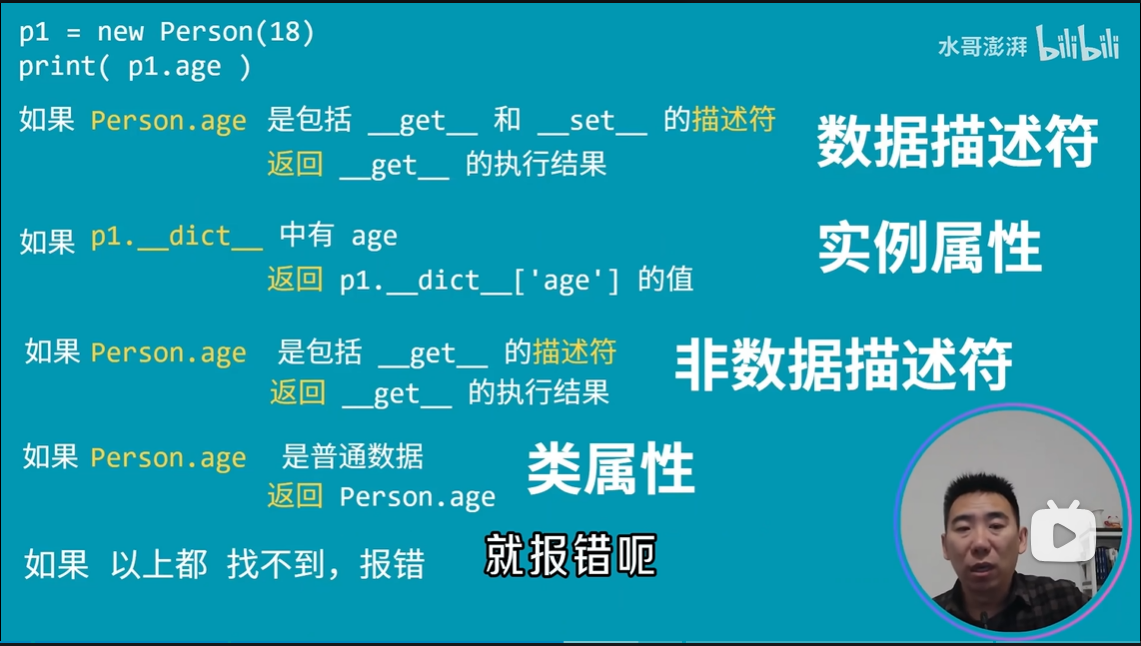

访问 p.age
  │
  ▼
先查 type(p) 即 Person 类 → 发现 age 是描述符 → 走描述符
  │
  ▼
如果类上没有 → 直接查实例 __dict__ → 普通属性

In [31]:
import numpy as np
a = np.array([1, 2, 3])
print(a)

[1 2 3]
